## **ReAct-агент на LangChain**

Агент рассчитывает, через какой период пользователь сможет накопить на желаемую финансовую цель, если откажется от кофе навынос.

**Пользователь вводит:**
* сумму, которую хочет накопить
* количество стаканов кофе навынос, которое потребляет в день/неделю/месяц и тп.
* текущую дату или дату, с которой хочет начать копить (если этого не сделать, агент попросит указать данную информацию)
* при желании, стоимость за стакан (если ее не указывать, агент считает с условием, что стоимость стакана кофе равна 300 руб)

**Агент:**
* рассчитывает время накопления с учетом инфляции 6% (именно 6%, потому что Среднегодовая инфляция в России по данным Росстата была около 6% в период с 2010 по 2022, согласно источнику: https://habr.com/ru/articles/891212/)
* выводит количество лет (если копить больше кода), месяцев и дней, которое потребуется пользователю, чтобы накопить на желаемую цель.

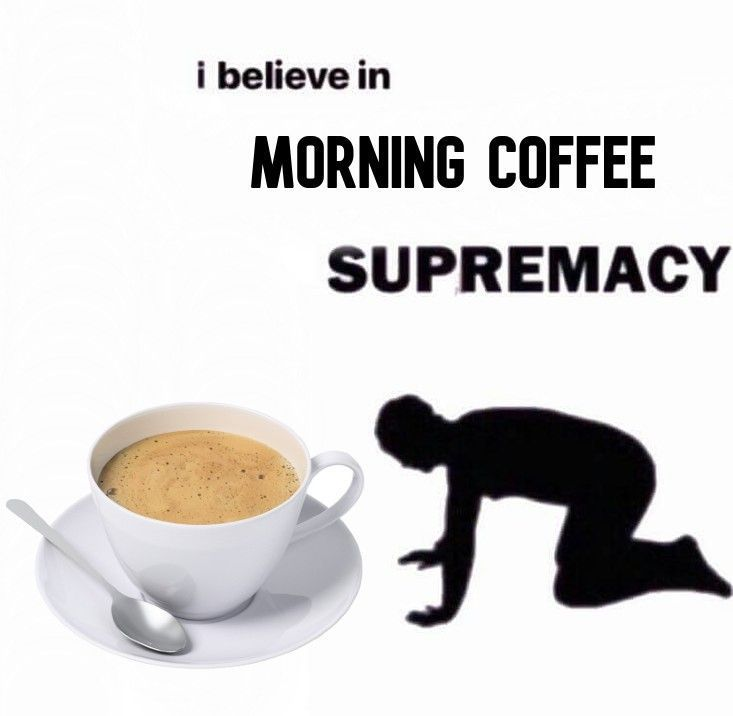

In [ ]:
pip install --upgrade langchain langchain-core langchain-openai

In [ ]:
OPENROUTER_TOKEN = ''

In [ ]:
from langchain_openai import ChatOpenAI

llm = ChatOpenAI(
    api_key=OPENROUTER_TOKEN,
    base_url="https://openrouter.ai/api/v1",
    model="deepseek/deepseek-chat-v3.1"
)

response = llm.invoke("Привет! Как твои дела?").content
print(response)

Привет! 😊 У меня всё отлично, как у цифрового помощника. Работаю стабильно, всегда готов помочь. Спасибо, что спросили! А как ваши дела?


In [ ]:
from langchain_core.prompts import ChatPromptTemplate, MessagesPlaceholder
from langchain_core.runnables.base import RunnableSerializable
from langchain_core.messages import HumanMessage, AIMessage, ToolMessage
from langchain_core.tools import tool
from langchain_core.chat_history import InMemoryChatMessageHistory
from langchain.memory import ConversationBufferMemory

import numexpr
import math
import json
from datetime import datetime, timedelta
from dateutil.relativedelta import relativedelta

@tool
def calculator(expression: str) -> str:
    """
    Вычисляет математические выражения
    """
    local_dict = {"pi": math.pi, "e": math.e}
    result = numexpr.evaluate(expression.strip(), global_dict={}, local_dict=local_dict)
    return str(result)


@tool
def savings_period(daily_saving: float, target: float, start_date: str, daily_growth: float) -> str:
    """
    Рассчитывает точный период накопления с учетом инфляции
     """
    start = datetime.strptime(start_date, "%Y-%m-%d")
    if daily_saving <= target * (daily_growth - 1):
      return json.dumps({
            "error": "Ежедневная экономия слишком мала, чтобы покрыть рост цели из-за инфляции."
        }, ensure_ascii=False)
    day = 0
    saved = 0.0
    current_saving = daily_saving
    while True:
      current_target = target * (daily_growth ** day)
      if saved >= current_target:
          break
      day += 1
      saved += current_saving
      current_saving *= daily_growth

    end = start + timedelta(days=day)
    delta = relativedelta(end, start)

    result = {
        "years": delta.years,
        "months": delta.months,
        "days": delta.days,
        "end_date": end.strftime("%d.%m.%Y") if delta.years > 0 else None,
    }
    return json.dumps(result, ensure_ascii=False)

In [ ]:
tools = [calculator, savings_period]
name2tool = {t.name: t.func for t in tools}

message_history = InMemoryChatMessageHistory()
memory = ConversationBufferMemory(
    chat_memory=message_history,
    return_messages=True,
    memory_key="chat_history"
)

history_analysis_prompt = ChatPromptTemplate.from_messages([
    ("system", (
        "Извлеки из истории диалога параметры пользователя в формате JSON, при необходимости приведи их к нужному формату:\n"
        "cups_per_week: количество чашек кофе в неделю (формат: целое число)\n"
        "target: сумма цели накопления (формат: целое число)\n"
        "start_date: дата начала (формат: ГГГГ-ММ-ДД)\n"
        "price_per_cup: цена за чашку (формат: целое число)\n"
        "Верни только JSON."
    )),
    MessagesPlaceholder(variable_name="chat_history"),
    ("human", "Какие данные о кофе и цели накопления известны?"),
])

agent_prompt = ChatPromptTemplate.from_messages([
    ("system", (
        "Ты помогаешь считать, сколько времени понадобится, чтобы накопить на желаемую цель пользователя, если отказаться от кофе навынос.\n"
        "У тебя есть два инструмента:\n"
        "1) calculator – выполняет любые математические выражения.\n"
        "2) savings_period – рассчитывает период накопления (нужны daily_saving, target, start_date, daily_growth).\n\n"
        "Действуй по инструкции:\n"
        "1) Если пользователь указал частоту потребления кофе навынос в день/неделю/месяц, переведи в чашки в неделю через calculator. Пример: 3 чашки в день - это 3*7 = 21 чашка в неделю\n"
        "2) Если пользователь не указал цену за чашку кофе, используй 300 руб.\n"
        "3) Если пользователь не указал дату начала накопления, спроси ее.\n"
        "4) Если пользователь ввел дату не в формате ГГГГ-ММ-ДД, преобразуй к требуемому, например 22.03.2026 необходимо привести к виду 2026-03-22\n"
        "5) Вычисли ежедневную экономию - daily_saving - через calculator: (количество чашек в неделю * цена чашки) / 7.\n"
        "6) Вычисли ежедневный множитель инфляции - daily_growth - через calculator: (1 + 6/100) ** (1 / 365).\n"
        "7) Вызови savings_period с полученными daily_saving, target, start_date, daily_growth.\n"
        "8) Если в ответе savings_period содержится поле 'error', сразу верни это сообщение пользователю.\n"
        "9) Иначе из полученного JSON возьми years, months, days, end_date.\n"
        "10) Оформи ответ пользователю, правильно склоняя годы, месяцы, дни.\n"
        "11) Если количество лет равно 0, не упоминай про годы и не выводи end_date.\n"
        "12) Если количество лет больше 0, добавь к ответу год, к которому цель будет достигнута.\n"
        "13) Учитывай историю: если пользователь уже сообщал параметры ранее, не спрашивай их снова.\n"
    )),
    ("human", "Текущие параметры пользователя: {history_analysis}"),
    ("human", "{input}"),
    MessagesPlaceholder(variable_name="agent_scratchpad"),
])

/tmp/ipykernel_1017/926459992.py:5: LangChainDeprecationWarning: Please see the migration guide at: https://python.langchain.com/docs/versions/migrating_memory/
  memory = ConversationBufferMemory(


In [ ]:
agent: RunnableSerializable = (
    {
        "input": lambda x: x["input"],
        "chat_history": lambda x: x["chat_history"],
        "agent_scratchpad": lambda x: x.get("agent_scratchpad", [])
    }
    | {
        "history_analysis": lambda x: llm.invoke(history_analysis_prompt.format_messages(
            chat_history=x["chat_history"]
        )).content,
        "input": lambda x: x["input"],
        "agent_scratchpad": lambda x: x.get("agent_scratchpad", [])
    }
    | agent_prompt
    | llm.bind_tools(tools, tool_choice="auto")
)

In [ ]:
class CustomAgentExecutor:
    def __init__(self, max_iterations: int = 5):
        self.max_iterations = max_iterations
        self.chat_history = []
        self.agent = agent

    def invoke(self, user_input: str) -> str:
        count = 0
        agent_scratchpad = []

        while count < self.max_iterations:
            tool_call = self.agent.invoke({
                "input": user_input,
                "chat_history": self.chat_history,
                "agent_scratchpad": agent_scratchpad
            })
            agent_scratchpad.append(tool_call)

            if tool_call.tool_calls:
                for tool_call_obj in tool_call.tool_calls:
                    tool_name = tool_call_obj["name"]
                    tool_args = tool_call_obj["args"]
                    tool_call_id = tool_call_obj["id"]

                    tool_out = name2tool[tool_name](**tool_args)

                    tool_exec = ToolMessage(
                        content=f"{tool_out}",
                        tool_call_id=tool_call_id
                    )
                    agent_scratchpad.append(tool_exec)

                    print(f"{count}: {tool_name}({tool_args}) -> {tool_out}")

                count += 1
            else:
                final_answer = tool_call.content
                break

        self.chat_history.append(HumanMessage(content=user_input))
        self.chat_history.append(AIMessage(content=final_answer))
        return final_answer

In [ ]:
conversational_agent = CustomAgentExecutor()

In [ ]:
result = conversational_agent.invoke('Я пью 2 кофе в день 5 раз в неделю, через сколько я смогу накопить на айфон за 80 тыс. руб., если откажусь от кофе навынос?')
print(result)

Для расчета периода накопления на iPhone за 80 тыс. руб. мне нужно знать дату, с которой вы планируете начать откладывать деньги. 

Пожалуйста, укажите дату начала в формате ГГГГ-ММ-ДД (например, 2024-12-25).


In [ ]:
result = conversational_agent.invoke('Давай считать от текущей даты 22.03.2026')
print(result)

0: calculator({'expression': '10 * 300 / 7'}) -> 428.57142857142856
1: calculator({'expression': '(1 + 6/100) ** (1 / 365)'}) -> 1.0001596535874528
2: savings_period({'daily_growth': 1.0001596535874528, 'daily_saving': 428.57142857142856, 'start_date': '2026-03-22', 'target': 80000}) -> {"years": 0, "months": 6, "days": 6, "end_date": null}
Отлично! Если вы откажетесь от кофе навынос (10 чашек в неделю по 300 рублей), то сможете накопить на цель в 80 000 рублей за:

**6 месяцев и 6 дней**

Начнете накапливать с 22 марта 2026 года.


In [ ]:
result = conversational_agent.invoke('Я пью оверпрайс кофе за 500 рублей 3 раза в неделю, но хочу накопить первоначальный взнос 5 млн. руб. на квартиру, через сколько лет я смогу это сделать, если откажусь от своей привычки?')
print(result)

0: calculator({'expression': '3 * 500'}) -> 1500
1: calculator({'expression': '1500 / 7'}) -> 214.28571428571428
2: calculator({'expression': '(1 + 6/100) ** (1 / 365)'}) -> 1.0001596535874528
3: savings_period({'daily_growth': 1.0001596535874528, 'daily_saving': 214.28571428571428, 'start_date': '2026-03-22', 'target': 5000000}) -> {"error": "Ежедневная экономия слишком мала, чтобы покрыть рост цели из-за инфляции."}
К сожалению, при текущих условиях накопить 5 млн рублей отказавшись от кофе не получится.

Ваши параметры:
- Экономия в день: 214,29 рублей (3 чашки в неделю × 500 рублей = 1500 руб/неделю)
- Целевая сумма: 5 000 000 рублей

Расчет показывает, что ежедневная экономия (214,29 руб) слишком мала для покрытия роста цели из-за инфляции (6% годовых). Это означает, что инфляция будет "съедать" вашу экономию быстрее, чем вы сможете накопить.

Для достижения такой крупной цели как первоначальный взнос в 5 млн рублей вам потребуется либо:
- Увеличить экономию (отказаться от большег

In [ ]:
result = conversational_agent.invoke('А если я пью по 2 стакана кофе стоимостью 500 руб 7 дней в неделю? Так я смогу накопить на первоначальный взнос 5 млн?')
print(result)

0: calculator({'expression': '2 * 7'}) -> 14
1: calculator({'expression': '(14 * 500) / 7'}) -> 1000.0
2: calculator({'expression': '(1 + 6/100) ** (1 / 365)'}) -> 1.0001596535874528
3: savings_period({'daily_growth': 1.0001596535874528, 'daily_saving': 1000.0, 'start_date': '2026-03-22', 'target': 5000000}) -> {"years": 27, "months": 5, "days": 13, "end_date": "04.09.2053"}
Если вы будете пить по 2 стакана кофе стоимостью 500 рублей 7 дней в неделю (что составляет 14 чашек в неделю), то:

Ежедневная экономия составит 1000 рублей.

Отказавшись от кофе навынос, вы сможете накопить 5 миллионов рублей за:
- 27 лет
- 5 месяцев  
- 13 дней

Цель будет достигнута к 4 сентября 2053 года.

Так что да, вы сможете накопить на первоначальный взнос 5 млн рублей, отказавшись от кофе навынос!


## **Агент на LangGraph**

Агент подбирает вакансии с агрегатора Adzuna.

**Пользователь вводит:**
* Профессию
* Город

**Агент:**
* обращается к adzuna api
* ищет подходящие вакансии (по фильтрам профессия и город)
* возвращает 5 вакансий с указанием позиции, места работы и зарплаты (если публикуется)

**Используемые ресурсы (чтобы разобраться с api):**
* https://developer.adzuna.com/activedocs#/default/search
* https://all-api.fr/api/detail/adzuna



In [ ]:
!pip install langgraph

In [ ]:
from typing import TypedDict, List
from langgraph.graph import START, END, StateGraph

class JobState(TypedDict):
  query: str
  country_code: str
  profession: str
  city: str
  jobs: list
  answer: str

In [ ]:
ADZUNA_API_ID = ""
ADZUNA_API_KEY = ""

In [ ]:
from langchain_openai import ChatOpenAI

llm = ChatOpenAI(
    api_key=OPENROUTER_TOKEN,
    base_url="https://openrouter.ai/api/v1",
    model="deepseek/deepseek-chat-v3.1"
)

# response = llm.invoke("Привет! Как твои дела?").content
# print(response)

In [ ]:
import requests

"""Ищет вакансии из агрегатора Adzuna"""
def get_data_from_question(state: JobState) -> dict:
  prompt = f"""
  Из вопроса пользователя: "{state.get('query', '')}"
  Извлеки город, страну и профессию, переведенные на английский язык.
  Определи двухбуквенный код страны (ISO 8601).
  Верни три слова через запятую в следующем порядке: город, профессия, код страны.
  Пример 1: Paris, data analyst, fr
  Пример 2: London, programmer, gb
  Пример 3: Berlin, teacher, de
  """
  response = llm.invoke(prompt).content.strip()
  parts = [p.strip() for p in response.split(',')]
  if len(parts) == 3:
    city = parts[0]
    profession = parts[1]
    country_code = parts[2]
  else:
    return {'answer': f'Не удалось распознать: {response}'}

  if not city or not profession or not country_code:
    return {'answer': 'Не удалось распознать информацию из запроса'}
  return {'city': city, 'profession': profession, 'country_code': country_code}

"""Ищет вакансии из агрегатора Adzuna """
def search_jobs(state: JobState) -> dict:
  city = state['city']
  profession = state['profession']
  country_code = state['country_code']

  url = f"https://api.adzuna.com/v1/api/jobs/{country_code}/search/1"
  params = {
        "app_id": ADZUNA_API_ID,
        "app_key": ADZUNA_API_KEY,
        "what": profession,
        "where": city,
        "results_per_page": 20}

  response = requests.get(url, params=params)
  formatted = []
  if response.status_code == 200:
    data = response.json()
    jobs = data.get('results', [])

    for job in jobs[:5]:
      title = job.get('title', 'Название не указано')
      company = job.get('company', {}).get('display_name', 'Не указана')

      prompt = f"Переведи на русский язык: '{title}'. Верни только перевод без дополнительных символов и пояснений"
      title_ru = llm.invoke(prompt).content.strip()

      salary = ""
      if job.get('salary_min') and job.get('salary_max'):
        salary = f"{job['salary_min']:.0f} - {job['salary_max']:.0f} {job.get('salary_currency', 'EUR')}"
      elif job.get('salary_min'):
        salary = f"от {job['salary_min']:.0f} {job.get('salary_currency', 'EUR')}"
      elif job.get('salary_max'):
        salary = f"до {job['salary_max']:.0f} {job.get('salary_currency', 'EUR')}"
      if salary:
        formatted.append(f"{title_ru} — {company}\n{salary}")
      else:
        formatted.append(f"{title_ru} — {company}")
  return {'jobs': formatted, 'city': city, 'profession': profession}

"""Формирует ответ пользователю на русском языке"""
def format_answer(state: JobState) -> dict:
  profession = state.get('profession', '')
  city = state.get('city', '')
  jobs = state.get('jobs', [])

  if not jobs:
    prompt = f"Переведи на русский язык: 'Не найдено вакансий для {profession} в {city}'. Верни только перевод без дополнительных символов и пояснений"
    translation = llm.invoke(prompt).content.strip()
    return {'answer': f"{translation}\n\n Попробуйте поискать другую локацию или профессию"}

  prompt = f"Переведи на русский язык: 'Вакансии для {profession} в {city}'. Верни только перевод без дополнительных символов и пояснений"
  header = llm.invoke(prompt).content.strip()

  text = f"{header}:\n\n"
  for job in jobs:
    text += f" - {job}\n\n"
  return {'answer': text}


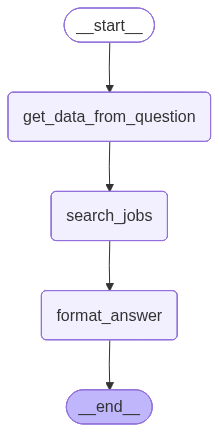

In [ ]:
graph_builder = StateGraph(JobState)


graph_builder.add_node('get_data_from_question', get_data_from_question)
graph_builder.add_node('search_jobs', search_jobs)
graph_builder.add_node('format_answer', format_answer)

graph_builder.add_edge(START, 'get_data_from_question')
graph_builder.add_edge('get_data_from_question', 'search_jobs')
graph_builder.add_edge('search_jobs', 'format_answer')
graph_builder.add_edge('format_answer', END)

graph = graph_builder.compile()
graph


In [ ]:
answer1 = graph.invoke({'query':'Найди вакансии аналитика в Париже'})['answer']
print(answer1)

Вакансии для аналитиков в Париже:

 - Кредитный аналитик (временная работа) — LHH

 - Финансовый аналитик - мужчина/женщина (ученичество/альтернация) — BANQUE DE FRANCE

 - Аналитик данных - м/ж (ученичество/альтернативное обучение) — BANQUE DE FRANCE

 - Аналитик — Réseau Entreprendre Paris

 - Бизнес-аналитик (стажер) — Soeur




In [ ]:
answer2 = graph.invoke({'query':'Найди вакансии инженера в Берлине'})['answer']
print(answer2)

Вакансии для инженера в Берлине:

 - Старший инженер SOC — N26 GmbH

 - Старший инженер Android в направлении инвестиций и накоплений — N26 GmbH

 - Старший инженер по безопасности облачных сервисов — N26 GmbH

 - Старший инженер бэкенда по вовлечению — N26 GmbH

 - Инженер — Hologic




In [ ]:
answer3 = graph.invoke({'query':'Найди вакансии доктора в Лондоне'})['answer']
print(answer3)

Вакансии для врача в Лондоне:

 - Врач-онкогематолог — Leaders In Care Recruitment Ltd
80000 - 80000 EUR

 - Врач-консультант-микробиолог (переезд в Ирландию) — MatchMedics
88539 - 88539 EUR

 - Врач-консультант по микробиологии (переезд в Ирландию) — MatchMedics
89412 - 89412 EUR

 - Врач-специалист — irecruiti
66220 - 66220 EUR

 - UCC врач — Woodston Personnel
71186 - 71186 EUR




In [ ]:
answer4 = graph.invoke({'query':'Найди вакансии охранника в Варшаве'})['answer']
print(answer4)

Не найдено вакансий для охранника в Варшаве

 Попробуйте поискать другую локацию или профессию


In [ ]:
answer5 = graph.invoke({'query':'Найди вакансии бухгалтера в Шанхае'})['answer']
print(answer5)

Не найдено вакансий для бухгалтера в Шанхае

 Попробуйте поискать другую локацию или профессию


## **Распознавание текстов**

In [1]:
%pip install bitsandbytes==0.48.2 transformers accelerate sentencepiece optimum torchmetrics

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 59.4/59.4 MB 16.3 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 161.2/161.2 kB 9.0 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 983.4/983.4 kB 35.7 MB/s eta 0:00:00


In [19]:
import os
import re
import tqdm
import zipfile
import torch
import transformers
import bitsandbytes as bnb
from PIL import Image, ImageEnhance
from transformers import (
    Qwen2_5_VLForConditionalGeneration,
    AutoProcessor,
    BitsAndBytesConfig
)

## **Загрузка файлов**

In [3]:
zip_path = '/content/pictures_iad.zip'
with zipfile.ZipFile(zip_path, 'r') as zip_ref:
  zip_ref.extractall('/content/dataset')

In [4]:
dataset_path = '/content/dataset'
image_files = sorted(
    [f for f in os.listdir(dataset_path) if f.endswith('.jpg')],
    key=lambda x: int(re.search(r'\d+', x).group())
)
print(f'Найдено картинок: {len(image_files)}')

Найдено картинок: 6


## **Обработка картинок**

In [20]:
def image_tuning(image):
  if image.mode != 'RGB':
    image = image.convert('RGB')

  w, h = image.size

  scale = min(1536 / max(w, h), 2.0)
  if scale != 1.0:
    image = image.resize((int(w * scale), int(h * scale)), Image.LANCZOS)

  enhancer = ImageEnhance.Contrast(image)
  image = enhancer.enhance(1.1)

  enhancer = ImageEnhance.Sharpness(image)
  image = enhancer.enhance(1.15)

  return image

## **Загрузка квантизированной модели: Qwen2.5-VL-7B**

In [6]:
model_name = 'Qwen/Qwen2.5-VL-7B-Instruct'

quantization_config = BitsAndBytesConfig(
    load_in_4bit=True,
    bnb_4bit_compute_dtype=torch.float16,
    bnb_4bit_quant_type='nf4',
    bnb_4bit_use_double_quant=True
)

model = Qwen2_5_VLForConditionalGeneration.from_pretrained(
    model_name,
    device_map='auto',
    torch_dtype=torch.float16,
    low_cpu_mem_usage=True,
    offload_state_dict=True,
    quantization_config=quantization_config,
)

/usr/local/lib/python3.12/dist-packages/huggingface_hub/utils/_auth.py:94: UserWarning: 
The secret `HF_TOKEN` does not exist in your Colab secrets.
To authenticate with the Hugging Face Hub, create a token in your settings tab (https://huggingface.co/settings/tokens), set it as secret in your Google Colab and restart your session.
You will be able to reuse this secret in all of your notebooks.
Please note that authentication is recommended but still optional to access public models or datasets.
  warnings.warn(


config.json: 0.00B [00:00, ?B/s]

model.safetensors.index.json: 0.00B [00:00, ?B/s]

Fetching 5 files:   0%|          | 0/5 [00:00<?, ?it/s]

Loading weights:   0%|          | 0/729 [00:00<?, ?it/s]

generation_config.json:   0%|          | 0.00/216 [00:00<?, ?B/s]

In [21]:
processor = AutoProcessor.from_pretrained(model_name)
device = torch.device('cuda' if torch.cuda.is_available() else 'cpu')
model.eval()

prompt = (
    "Read the handwritten text on the image and copy it verbatim. "
    "Output only the recognized text. Preserve the original wording. "
    "Do not add explanations."
)

@torch.no_grad()
def predict_text(image):
  messages = [
        {
            "role": "user",
            "content": [
                {"type": "image", "image": image},
                {"type": "text", "text": prompt},
            ],
        }
    ]

  text = processor.apply_chat_template(
        messages,
        tokenize=False,
        add_generation_prompt=True
    )

  inputs = processor(
        text=[text],
        images=[image],
        padding=True,
        return_tensors="pt"
        ).to(device)

  generated_ids = model.generate(
        **inputs,
        max_new_tokens=256,
        do_sample=False,
        use_cache=True
    )

  generated_ids_trimmed = [
        out_ids[len(in_ids):]
        for in_ids, out_ids in zip(inputs.input_ids, generated_ids)
    ]

  decoded = processor.batch_decode(
        generated_ids_trimmed,
        skip_special_tokens=True,
        clean_up_tokenization_spaces=False,
    )[0]

  return decoded.strip()

In [22]:
refs = [
    "Современные языки программирования, такие как Python, Java и C++, позволяют решать широкий спектр задач — от создания веб-сайтов до разработки сложных систем искусственного интеллекта. Каждый язык обладает своей философией и областью применения, но все они основаны на общих принципах: алгоритмах, структурах данных и логике.",
    "Программирование — это не просто технический навык, а особый способ мышления, позволяющий человеку создавать новые цифровые миры. В XXI веке оно стало универсальным языком взаимодействия с технологиями. Подобно тому как когда-то знание грамоты открывало доступ к культуре и науке, сегодня умение писать код открывает путь к инновациям, автоматизации и творчеству.",
    "История программирования начинается задолго до появления современных компьютеров. Идеи алгоритмов можно проследить ещё в работах математиков прошлого, а в XIX веке Ада Лавлейс создала описание алгоритма для аналитической машины, став первым в мире программистом. С развитием вычислительной техники программирование превратилось в самостоятельную область знаний, объединяющую математику, инженерию и логику.",
    "Это первая домашка на ИАДе.\nОна, кажется, простая, но пока никто её не решил...",
    "Сытость совсем не зависит от того,\nсколько мы едим, а от того, как мы едим!\nТак и счастье, так и счастье, Лёвушка,\nоно вовсе не зависит от объёма\nвнешних благ, которые мы урвали у\nжизни. Оно зависит только от нашего\nотношения к ним! Об этом сказано ещё в\nдаосской этике: «Кто умеет\nдовольствоваться, тот всегда будет\nдоволен.",
    "При наличии уважительной причины дедлайн по д/з может быть перенесён. Дедлайн по д/з переносится на кол-во дней, равное продолжительности ув. причины."
]

## **Детекция текста моделью**

In [23]:
preds = []

for img_file in tqdm.tqdm(image_files):
  img_path = os.path.join(dataset_path, img_file)
  image = Image.open(img_path).convert('RGB')
  image = image_tuning(image)

  text = predict_text(image)
  preds.append(text)

100%|██████████| 6/6 [01:14<00:00, 12.39s/it]


In [10]:
!pip install cer

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 153.3/153.3 kB 7.3 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 3.2/3.2 MB 72.5 MB/s eta 0:00:00


In [24]:
from cer import calculate_cer_corpus

hyps = [sent.split() for sent in preds]
refs = [sent.split() for sent in refs]
cer_corpus_score = calculate_cer_corpus(hyps, refs)
cer_corpus_score


{'count': 6,
 'mean': 0.18648054036942927,
 'median': 0.02807692307692308,
 'std': 0.3988880465694011,
 'min': 0.0,
 'max': 1.0,
 'cer_scores': [0.015432098765432098,
  0.019230769230769232,
  1.0,
  0.0,
  0.036923076923076927,
  0.0472972972972973]}

In [25]:
print(3 * min(1, 1 - cer_corpus_score["mean"] + 0.19))

3
